# 月度销售额

=== 月度销售额 ===
InvoiceDate
2010-12-01     539059.660
2011-01-01     542847.160
2011-02-01     425524.080
2011-03-01     551034.820
2011-04-01     435234.611
2011-05-01     627392.660
2011-06-01     585988.500
2011-07-01     572608.371
2011-08-01     617273.950
2011-09-01     913837.022
2011-10-01     969174.730
2011-11-01    1101377.980
2011-12-01     502503.210
Freq: MS, Name: TotalAmount, dtype: float64


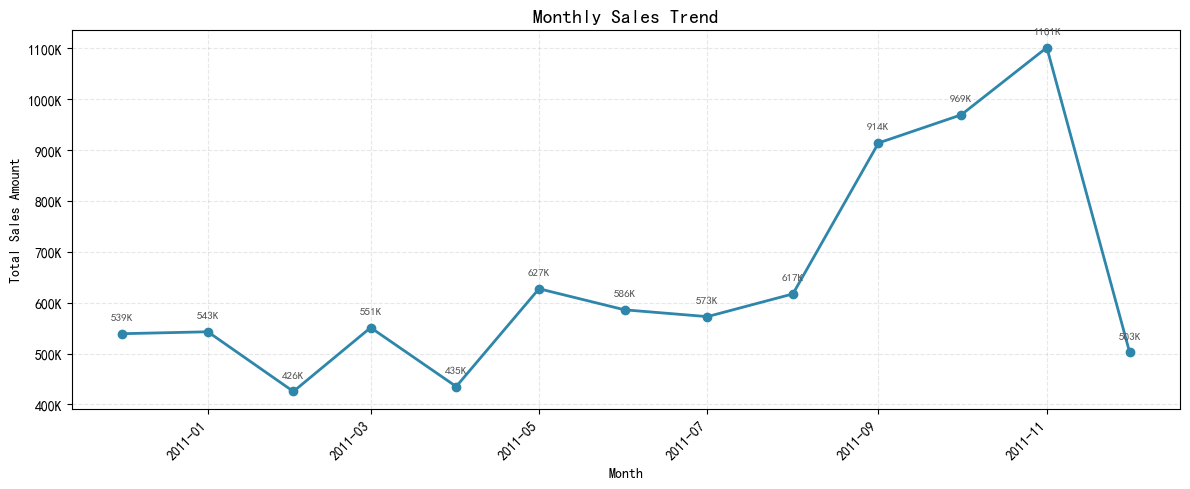

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
df = pd.read_excel('./Data/Online_Retail_Cleaned.xlsx')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df_sales = df[~df['InvoiceNo'].str.startswith('C', na=False)].copy()

# 计算月度销售额
monthly_sales = df_sales.groupby(df_sales['InvoiceDate'].dt.to_period('M'))['TotalAmount'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

# 打印实际数值查看
print("=== 月度销售额 ===")
print(monthly_sales)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(monthly_sales.index, monthly_sales.values, 
        marker='o', linewidth=2, markersize=6, color='#2E86AB')

ax.set_title('Monthly Sales Trend', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales Amount')

# 禁用科学计数法，y轴直接显示完整数值
ax.yaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, pos: f'{x/1000:.0f}K' if x >= 1000 else f'{x:.0f}'
))

# 旋转x轴日期标签
plt.xticks(rotation=45, ha='right')

# 添加网格线
ax.grid(True, alpha=0.3, linestyle='--')

# 在数据点上方标注数值（可选，数据点少时建议开启）
for i, (date, value) in enumerate(monthly_sales.items()):
    ax.annotate(f'{value/1000:.0f}K', 
                xy=(date, value), 
                xytext=(0, 10), 
                textcoords='offset points',
                ha='center', fontsize=8, color='#555')

plt.tight_layout()
plt.savefig('./monthly_sales_trend.png', dpi=300)
plt.show()

# 2. 各国家销售额占比（Top 10）

=== 各国家销售额 ===


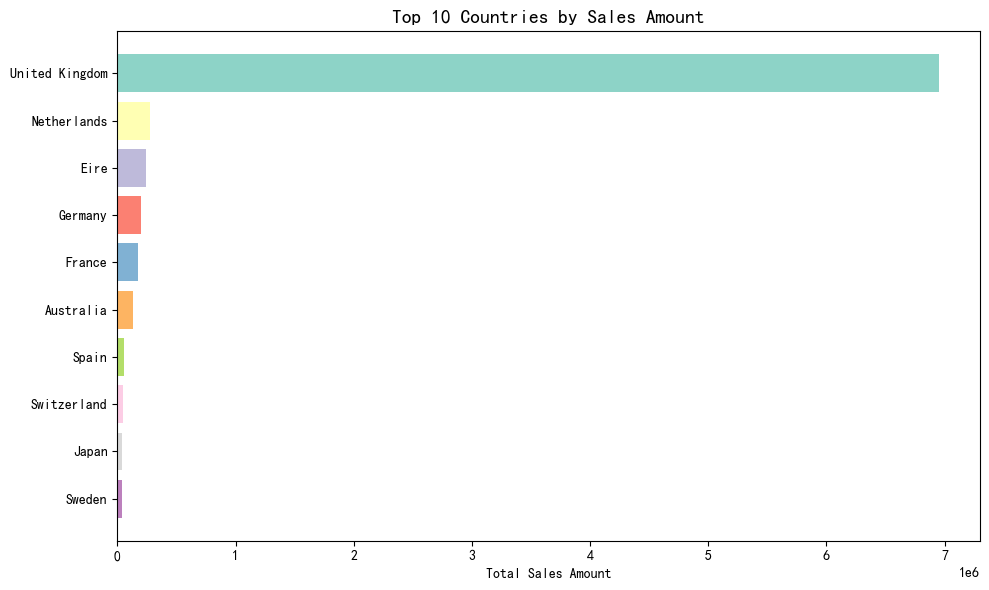

In [4]:
print("=== 各国家销售额 ===")

plt.figure(figsize=(10, 6))
country_sales = df_sales.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)

colors = plt.cm.Set3(range(len(country_sales)))
plt.barh(country_sales.index[::-1], country_sales.values[::-1], color=colors[::-1])
plt.title('Top 10 Countries by Sales Amount', fontsize=14)
plt.xlabel('Total Sales Amount')
plt.tight_layout()
plt.savefig('./top_countries_sales.png', dpi=300)
plt.show()

# 3. 每日各时段订单量分布

=== 各时段订单数量 ===


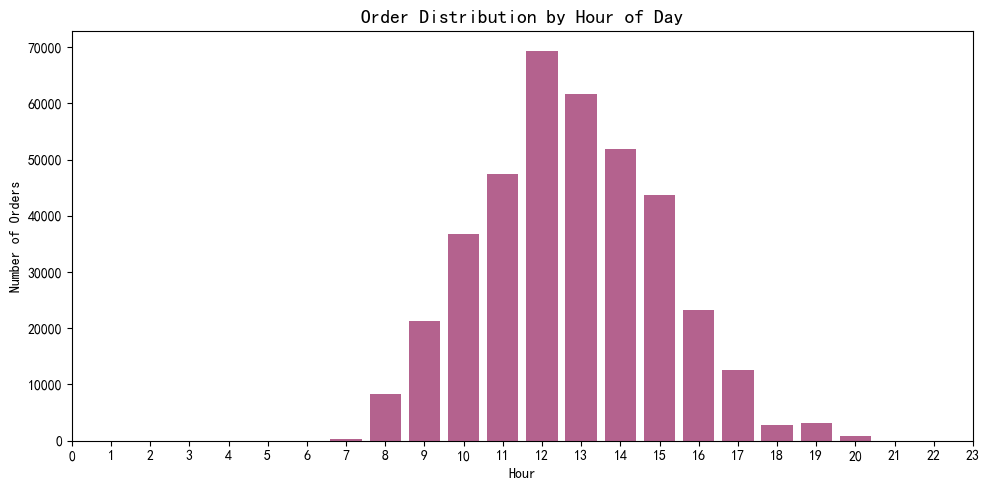

In [5]:
print("=== 各时段订单数量 ===")

plt.figure(figsize=(10, 5))
hourly_orders = df_sales.groupby('Hour').size()
plt.bar(hourly_orders.index, hourly_orders.values, color='#A23B72', alpha=0.8)
plt.title('Order Distribution by Hour of Day', fontsize=14)
plt.xlabel('Hour')
plt.ylabel('Number of Orders')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('./hourly_orders.png', dpi=300)
plt.show()

# 4. 热销商品 Top 10

=== Top 10 Best-Selling Products ===


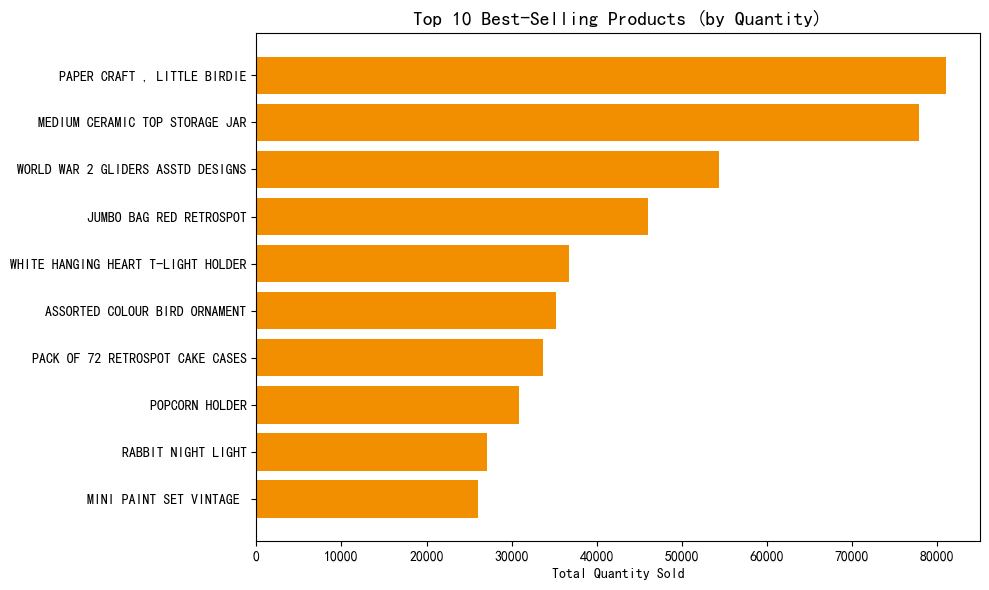

In [6]:
print("=== Top 10 Best-Selling Products ===")

plt.figure(figsize=(10, 6))
top_products = df_sales.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.barh(top_products.index[::-1], top_products.values[::-1], color='#F18F01')
plt.title('Top 10 Best-Selling Products (by Quantity)', fontsize=14)
plt.xlabel('Total Quantity Sold')
plt.tight_layout()
plt.savefig('./top_products.png', dpi=300)
plt.show()

# 5. 客单价分布（去除极端值）

=== 客单价分布 ===


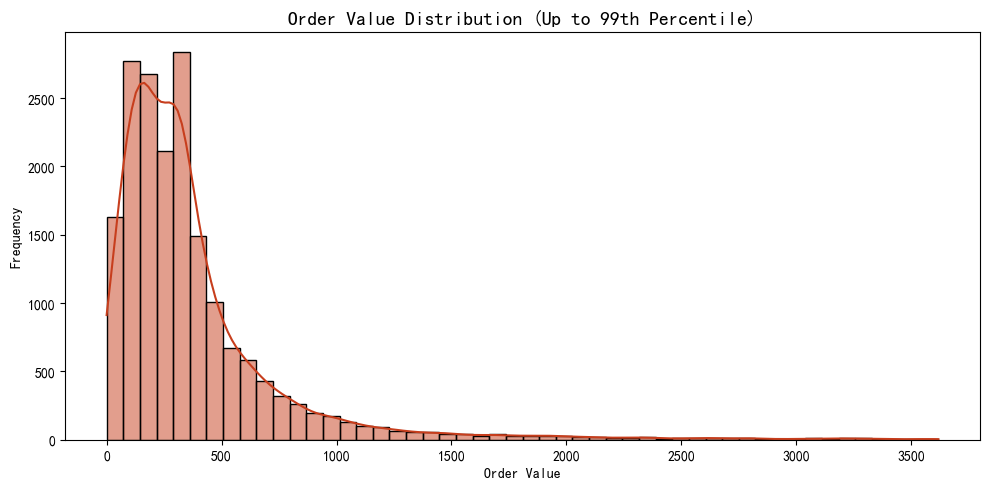

In [7]:
print("=== 客单价分布 ===")

plt.figure(figsize=(10, 5))
# 按订单聚合客单价
basket_value = df_sales.groupby('InvoiceNo')['TotalAmount'].sum()
# 过滤极端值（保留 99% 分位数以内）
basket_value_filtered = basket_value[basket_value <= basket_value.quantile(0.99)]

sns.histplot(basket_value_filtered, bins=50, kde=True, color='#C73E1D')
plt.title('Order Value Distribution (Up to 99th Percentile)', fontsize=14)
plt.xlabel('Order Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('./order_value_dist.png', dpi=300)
plt.show()

# 6. 星期几销售热度

=== 销售热度 ===


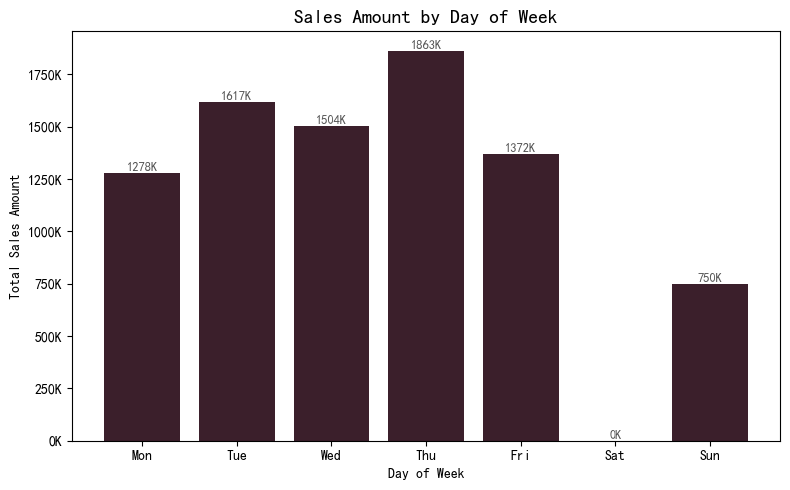

All visualizations saved successfully!


In [8]:
print("=== 销售热度 ===")

plt.figure(figsize=(8, 5))
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_sales = df_sales.groupby('DayOfWeek')['TotalAmount'].sum()

bars = plt.bar(range(7), [daily_sales.get(i, 0) for i in range(7)], color='#3B1F2B')
plt.xticks(range(7), day_names)
plt.title('Sales Amount by Day of Week', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Total Sales Amount')

# 禁用科学计数法，y轴直接显示完整数值(k)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K')
)

# 在柱子顶部标注数值
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., height,
             f'{height/1000:.0f}K',
             ha='center', va='bottom', fontsize=9, color='#555')

plt.tight_layout()
plt.savefig('./weekly_sales.png', dpi=300)
plt.show()

print("All visualizations saved successfully!")